In [1]:
from google.colab import files
files.upload()

Saving order_items_clean.csv to order_items_clean.csv
Saving orders_clean.csv to orders_clean.csv
Saving products_clean.csv to products_clean.csv
Saving reviews_clean.csv to reviews_clean.csv
Saving customers_clean.csv to customers_clean.csv


{'order_items_clean.csv': b'item_id,order_id,product_id,quantity,unit_price_idr,subtotal_idr,calculated_subtotal\nITM000001,ORD000001,PRD070,1,349000,349000,349000\nITM000002,ORD000001,PRD001,2,599000,1198000,1198000\nITM000003,ORD000001,PRD148,1,449000,449000,449000\nITM000004,ORD000002,PRD086,1,329000,329000,329000\nITM000005,ORD000002,PRD258,1,129000,129000,129000\nITM000006,ORD000002,PRD256,1,49000,49000,49000\nITM000007,ORD000003,PRD076,1,199000,199000,199000\nITM000008,ORD000004,PRD205,1,119000,119000,119000\nITM000009,ORD000005,PRD239,2,179000,358000,358000\nITM000010,ORD000006,PRD170,1,349000,349000,349000\nITM000011,ORD000007,PRD013,1,149000,149000,149000\nITM000012,ORD000007,PRD230,2,129000,258000,258000\nITM000013,ORD000008,PRD281,1,149000,149000,149000\nITM000014,ORD000008,PRD290,3,279000,837000,837000\nITM000015,ORD000009,PRD202,1,249000,249000,249000\nITM000016,ORD000010,PRD034,1,279000,279000,279000\nITM000017,ORD000011,PRD191,3,49000,147000,147000\nITM000018,ORD000011,P

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv("/content/orders_clean.csv")

In [4]:
#Make sure status is clean:
orders["order_status"] = (
    orders["order_status"]
    .str.strip()
    .str.lower()
)

In [8]:
#Order Status Distribution
status_counts = orders["order_status"].value_counts()

status_counts

,count
order_status,
delivered,1776
shipped,445
cancelled,328
processing,300
returned,151


In [6]:
status_percentage = (
    orders["order_status"]
    .value_counts(normalize=True) * 100
)

status_percentage.round(2)

,proportion
order_status,
delivered,59.20
shipped,14.83
cancelled,10.93
processing,10.00
returned,5.03


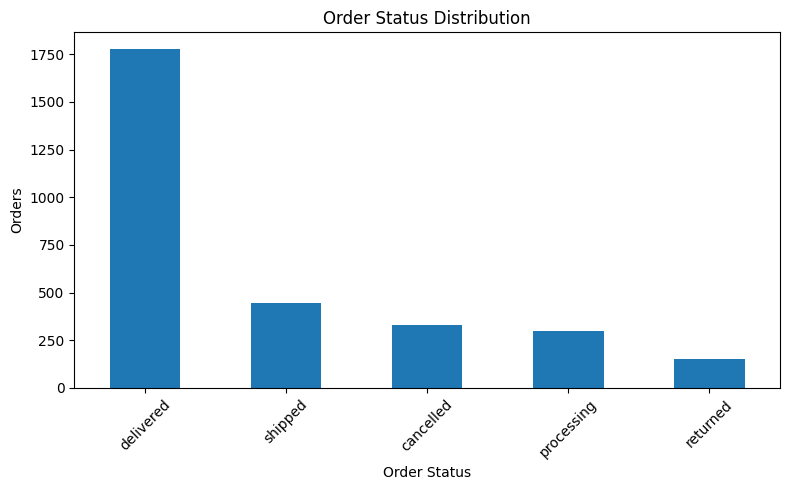

In [7]:
status_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
cancelled_orders = orders[
    orders["order_status"] == "cancelled"
]

cancellation_rate = len(cancelled_orders) / len(orders) * 100

print("Cancellation Rate:", round(cancellation_rate, 2))

Cancellation Rate: 10.93


In [14]:
#return rate
returned_orders = orders[
    orders["order_status"] == "returned"
]

return_rate = len(returned_orders) / len(orders) * 100

print("Return Rate:", round(return_rate, 2))

Return Rate: 5.03


In [15]:
#with percentage sign
print(f"Return Rate: {return_rate:.2f}%")

Return Rate: 5.03%


In [16]:
#Courier Order Volume
courier_orders = (
    orders["courier"]
    .value_counts()
)

courier_orders

,count
courier,
J&T,896
JNE,845
SiCepat,791
Anteraja,307
Pos Indonesia,161


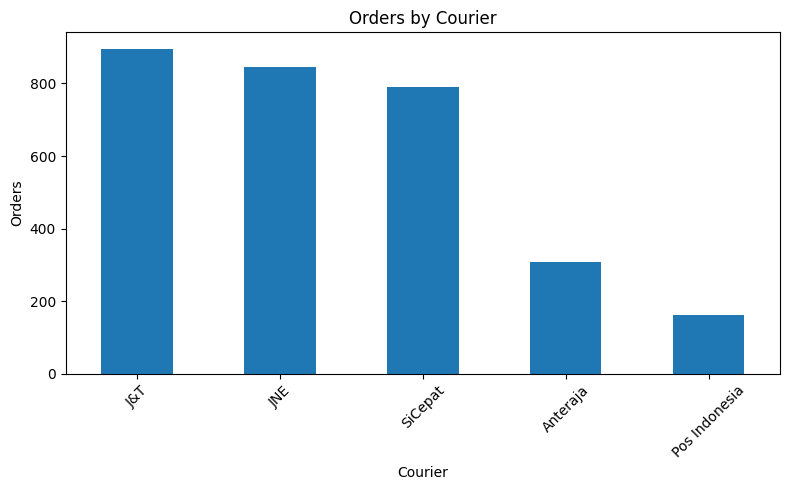

In [17]:
courier_orders.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Orders by Courier")
plt.xlabel("Courier")
plt.ylabel("Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [19]:
#Concellation rate by courier
courier_cancellation = (
    orders
    .groupby("courier")
    .agg(
        total_orders=("order_id", "nunique"),
        cancelled_orders=(
            "order_status",
            lambda x: (x == "cancelled").sum()
        )
    )
)
courier_cancellation

,total_orders,cancelled_orders
courier,,
Anteraja,307,44
J&T,896,111
JNE,845,84
Pos Indonesia,161,12
SiCepat,791,77


In [20]:
courier_cancellation[
    "cancellation_rate"
] = (
    courier_cancellation[
        "cancelled_orders"
    ] /
    courier_cancellation[
        "total_orders"
    ]
) * 100

In [21]:
#view
courier_cancellation.sort_values(
    "cancellation_rate",
    ascending=False
)

,total_orders,cancelled_orders,cancellation_rate
courier,,,
Anteraja,307,44,14.332248
J&T,896,111,12.388393
JNE,845,84,9.940828
SiCepat,791,77,9.734513
Pos Indonesia,161,12,7.453416


In [22]:
#Return Rate by Courier
courier_return = (
    orders
    .groupby("courier")
    .agg(
        total_orders=("order_id", "nunique"),
        returned_orders=(
            "order_status",
            lambda x: (x == "returned").sum()
        )
    )
)

In [23]:
courier_return["return_rate"] = (
    courier_return["returned_orders"] /
    courier_return["total_orders"]
) * 100

In [25]:
#view
courier_return.sort_values(
    "return_rate",
    ascending=False
)

,total_orders,returned_orders,return_rate
courier,,,
Pos Indonesia,161,11,6.832298
J&T,896,54,6.026786
JNE,845,43,5.088757
SiCepat,791,35,4.424779
Anteraja,307,8,2.605863


In [26]:
#Average Shipping Cost by Courier
shipping_by_courier = (
    orders
    .groupby("courier")[
        "shipping_cost_idr"
    ]
    .mean()
    .sort_values(ascending=False)
)

shipping_by_courier

,shipping_cost_idr
courier,
Anteraja,24239.938111
JNE,23926.766864
J&T,23368.194196
SiCepat,22802.165613
Pos Indonesia,22610.428571


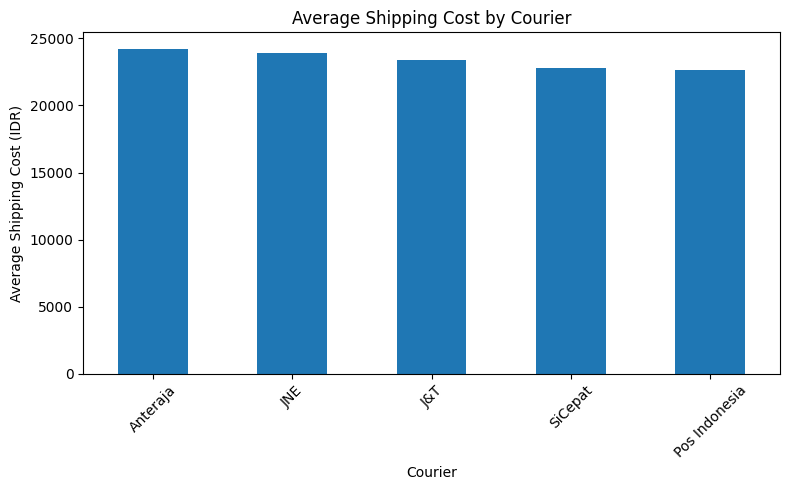

In [27]:
shipping_by_courier.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Shipping Cost by Courier")
plt.xlabel("Courier")
plt.ylabel("Average Shipping Cost (IDR)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [28]:
#Total Shipping Cost
total_shipping_cost = (
    orders["shipping_cost_idr"].sum()
)

print(
    f"Total Shipping Cost: "
    f"Rp {total_shipping_cost:,.0f}"
)

Total Shipping Cost: Rp 70,274,473


In [30]:
#avg
avg_shipping_cost = (
    orders["shipping_cost_idr"].mean()
)

print(
    f"Average Shipping Cost: "
    f"Rp {avg_shipping_cost:,.2f}"
)

Average Shipping Cost: Rp 23,424.82


In [32]:
#with percentage
print(f"Return Rate: {return_rate:.2f}%")

Return Rate: 5.03%


In [33]:
#shipping cost by province
'''How much shipping cost was charged for orders in each province/state.'''
province_shipping = (
    orders
    .groupby("shipping_province")[
        "shipping_cost_idr"
    ]
    .mean()
    .sort_values(ascending=False)
)

province_shipping.head(10)

,shipping_cost_idr
shipping_province,
Sulawesi Utara,38329.800000
Kalimantan Timur,37250.493421
Sulawesi Selatan,37192.772152
Kalimantan Barat,35115.769231
Kalimantan Selatan,35052.153285
Sumatera Utara,32704.367021
Sumatera Barat,30216.320896
Sumatera Selatan,28930.028169
Riau,27787.068182


In [35]:
#Cancellation Rate by Province
province_cancellation = (
    orders
    .groupby("shipping_province")
    .agg(
        total_orders=("order_id", "nunique"),
        cancelled_orders=(
            "order_status",
            lambda x: (x == "cancelled").sum()
        )
    )
)
province_cancellation

,total_orders,cancelled_orders
shipping_province,,
Bali,128,15
Banten,152,10
Di Yogyakarta,121,18
Dki Jakarta,137,15
Jawa Barat,608,63
Jawa Tengah,163,15
Jawa Timur,299,28
Kalimantan Barat,169,14
Kalimantan Selatan,137,25


In [36]:
province_cancellation[
    "cancellation_rate"
] = (
    province_cancellation[
        "cancelled_orders"
    ] /
    province_cancellation[
        "total_orders"
    ]
) * 100

In [37]:
province_cancellation.sort_values(
    "cancellation_rate",
    ascending=False
).head(10)

,total_orders,cancelled_orders,cancellation_rate
shipping_province,,,
Kalimantan Selatan,137,25,18.248175
Sulawesi Utara,180,28,15.555556
Di Yogyakarta,121,18,14.876033
Sumatera Utara,188,27,14.361702
Riau,132,18,13.636364
Kalimantan Timur,152,20,13.157895
Bali,128,15,11.718750
Dki Jakarta,137,15,10.948905
Jawa Barat,608,63,10.361842


In [38]:
#Payment Method vs Cancellation
payment_cancellation = (
    orders
    .groupby("payment_method")
    .agg(
        total_orders=("order_id", "nunique"),
        cancelled_orders=(
            "order_status",
            lambda x: (x == "cancelled").sum()
        )
    )
)

In [39]:
payment_cancellation[
    "cancellation_rate"
] = (
    payment_cancellation[
        "cancelled_orders"
    ] /
    payment_cancellation[
        "total_orders"
    ]
) * 100

In [40]:
payment_cancellation.sort_values(
    "cancellation_rate",
    ascending=False
)

,total_orders,cancelled_orders,cancellation_rate
payment_method,,,
OVO,588,77,13.095238
Kartu Kredit,445,53,11.910112
Transfer Bank,907,93,10.253583
GoPay,754,76,10.079576
QRIS,306,29,9.477124


In [41]:
#Discount vs Cancellation
orders["discount_status"] = np.where(
    orders["discount_amount_idr"] > 0,
    "Discount Used",
    "No Discount"
)

In [42]:
discount_cancellation = (
    orders
    .groupby("discount_status")
    .agg(
        total_orders=("order_id", "nunique"),
        cancelled_orders=(
            "order_status",
            lambda x: (x == "cancelled").sum()
        )
    )
)

In [43]:
discount_cancellation[
    "cancellation_rate"
] = (
    discount_cancellation[
        "cancelled_orders"
    ] /
    discount_cancellation[
        "total_orders"
    ]
) * 100

discount_cancellation

,total_orders,cancelled_orders,cancellation_rate
discount_status,,,
Discount Used,1214,128,10.543657
No Discount,1786,200,11.198208


In [44]:
#Operations KPI Summary
operations_summary = {
    "Total Orders":
        orders["order_id"].nunique(),

    "Cancelled Orders":
        len(cancelled_orders),

    "Cancellation Rate (%)":
        cancellation_rate,

    "Returned Orders":
        len(returned_orders),

    "Return Rate (%)":
        return_rate,

    "Total Shipping Cost":
        total_shipping_cost,

    "Average Shipping Cost":
        avg_shipping_cost
}

for key, value in operations_summary.items():
    print(f"{key}: {value}")

Total Orders: 3000
Cancelled Orders: 328
Cancellation Rate (%): 10.933333333333334
Returned Orders: 151
Return Rate (%): 5.033333333333333
Total Shipping Cost: 70274473
Average Shipping Cost: 23424.824333333334


In [ ]:
## Day 4 Business Observations
'''
- The overall cancellation rate was ____%.
- The overall return rate was ____%.
- ______ handled the highest number of orders.
- ______ had the highest cancellation rate among couriers.
- ______ had the highest return rate among couriers.
- The average shipping cost was Rp ______.
- ______ had the highest average shipping cost.
- ______ province had the highest average shipping cost.
- Cancellation rates differed across payment methods, with ______ showing the highest rate.
'''